# Customer Segmentation using KMeans

This project segments customers based on Annual Income and Spending Score using KMeans clustering.

In [25]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [26]:
# Load dataset
data = pd.read_csv("../data/Mall_Customers.csv")


print("Dataset shape:", data.shape)
data.head()

Dataset shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

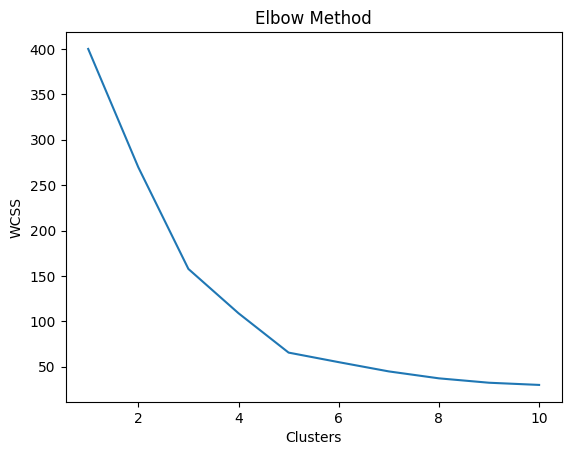

In [28]:
# Elbow Method
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [29]:
# Train final model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters

# Silhouette score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


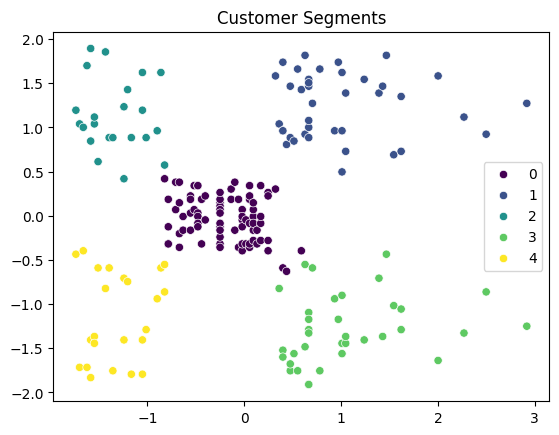

In [30]:
# Visualization
sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=clusters,
    palette="viridis"
)

plt.title("Customer Segments")
plt.show()

In [31]:
# Save model
joblib.dump(kmeans, "kmeans_model.pkl")

print("Model saved successfully")

Model saved successfully
